In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

In [2]:
# TODO: change name if needed
name = "Mrk501"
blazar_coord = SkyCoord.from_name(name)
# TODO: change data_folder if needed
data_folder = "../cta_dc_data/mrk_501/"
data_folder_40deg = data_folder+"40deg/"
data_folder_20deg = data_folder+"20deg/"
irf_file_40deg = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"
irf_file_20deg = "../cta_dc_data/irfs/Prod5-North-20deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus_40deg = []
hbus_20deg = []
for filename in os.listdir(data_folder_40deg):
    hbus_40deg.append(fits.open(data_folder_40deg + filename))
for filename in os.listdir(data_folder_20deg):
    hbus_20deg.append(fits.open(data_folder_20deg + filename))
    
irf_40deg = load_irf_dict_from_file(irf_file_40deg)
irf_20deg = load_irf_dict_from_file(irf_file_20deg)
print(f"Pointings 40deg: {len(hbus_40deg)}")
print(f"Pointings 20deg: {len(hbus_20deg)}")

Pointings 40deg: 60
Pointings 20deg: 66


In [4]:
e_bins=np.logspace(np.log10(0.01), np.log10(10), 11)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

#th2_bins=np.linspace(0,0.16,17)
th2_bins=np.linspace(0,0.16,34)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
def collect_data(hbus):
    cts_s = np.zeros((len(e), len(th2)))
    cts_b = np.zeros((len(e), len(th2)))
    t_expo = 0

    for hbu in hbus:
        data_raw = hbu["EVENTS"].data
    
        t = data_raw["TIME"]
        t = np.sort(t)
        t_expo += t[-1] - t[0]
    
        coord = SkyCoord(
            ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
        )
    
        pointing_coord = SkyCoord(
            ra=hbu[1].header["RA_PNT"] * u.deg,
            dec=hbu[1].header["DEC_PNT"] * u.deg,
            frame="icrs",
        )
    
        bkg_center = SkyCoord(
            l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
            b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
            frame="galactic",
        )
        
        seps = coord.separation(blazar_coord).degree
        seps_b = coord.separation(bkg_center).degree
        src_pos_mask = seps < bkg_subtraction_radius
        bkg_pos_mask = seps_b < bkg_subtraction_radius
    
        energ = data_raw["ENERGY"]
    
        for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
            m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
            m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask
    
            h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
            h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
            
            cts_s[i] += h_s
            cts_b[i] += h_b
    return cts_s, cts_b, t_expo

In [6]:
bkg_subtraction_radius = 0.4

cts_s_40deg, cts_b_40deg, t_expo_40deg = collect_data(hbus_40deg)
cts_s_20deg, cts_b_20deg, t_expo_20deg = collect_data(hbus_20deg)

print(f"Exposure time 40deg = {t_expo_40deg/60/60:.1f}h")
print(f"Exposure time 20deg = {t_expo_20deg/60/60:.1f}h")

Exposure time 40deg = 8.5h
Exposure time 20deg = 9.3h


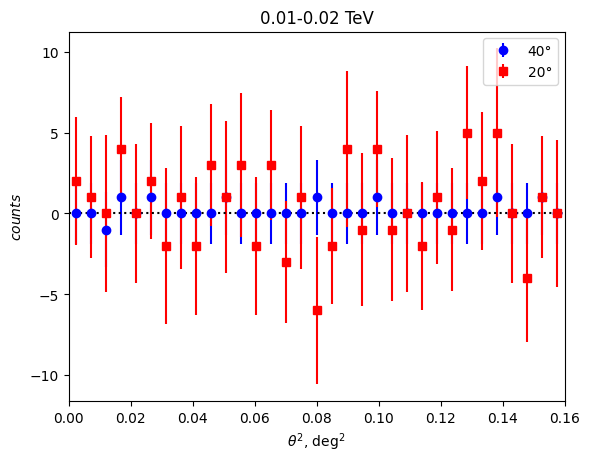

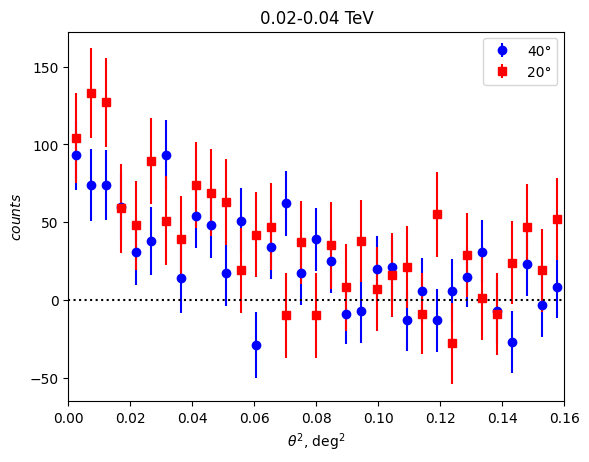

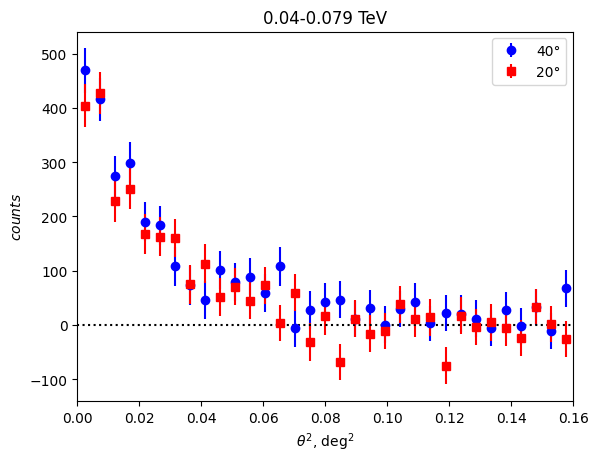

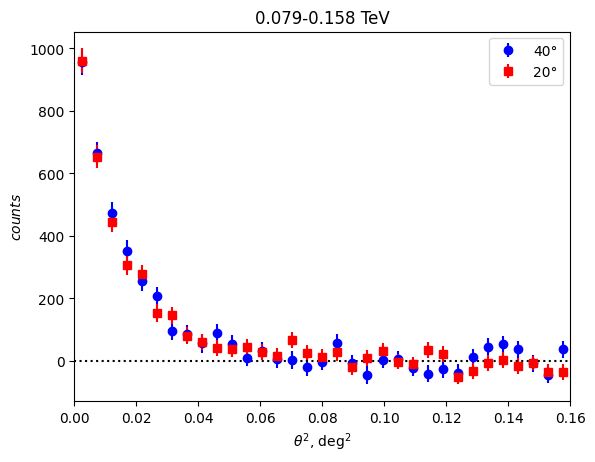

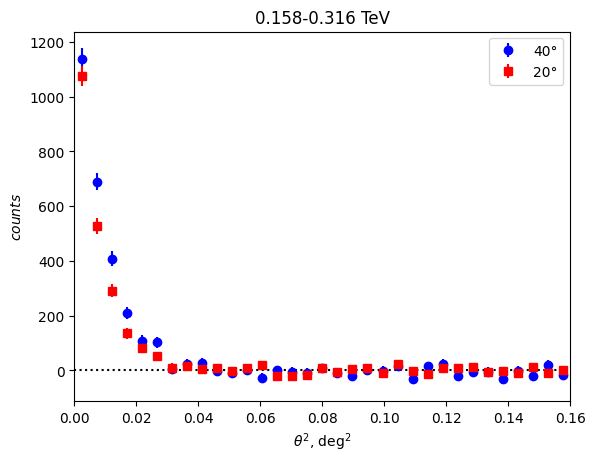

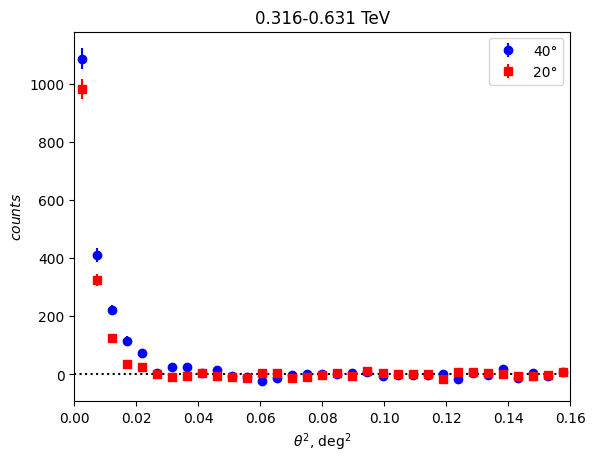

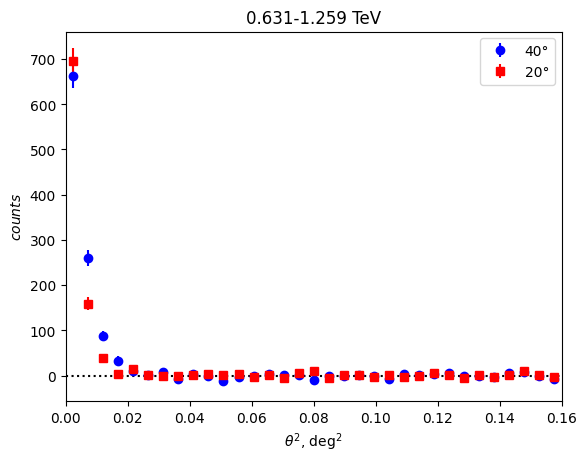

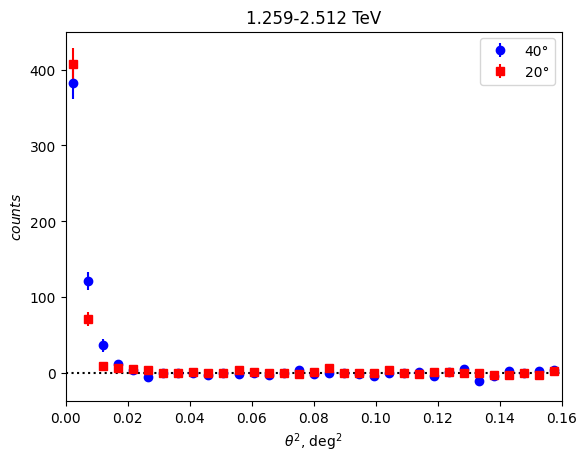

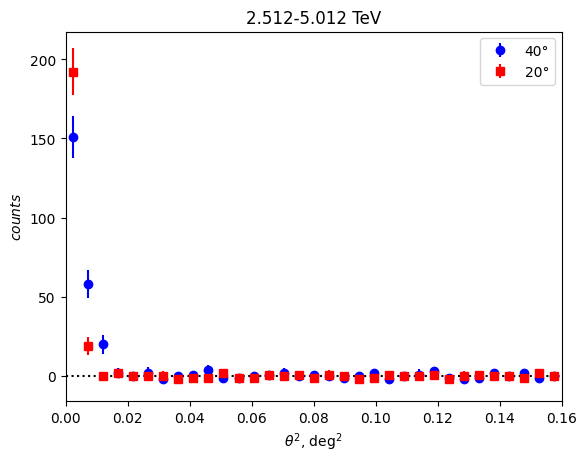

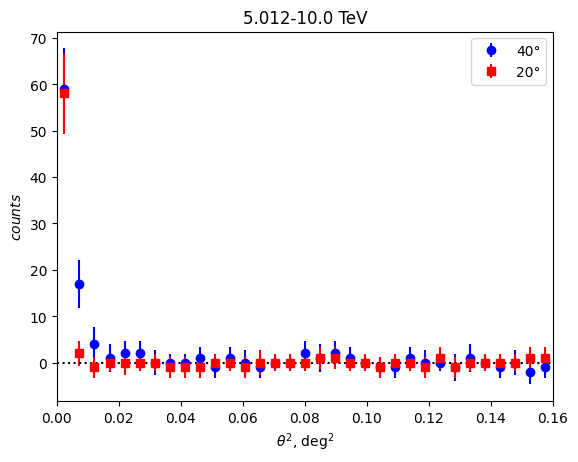

In [7]:
cts_40deg = cts_s_40deg - cts_b_40deg
cts_err_40deg = 1 + np.sqrt(cts_s_40deg + cts_b_40deg + 0.75)

cts_20deg = cts_s_20deg - cts_b_20deg
cts_err_20deg = 1 + np.sqrt(cts_s_20deg + cts_b_20deg + 0.75)

for i, ((cts_40, cts_err_40), (cts_20, cts_err_20)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
    plt.figure()
    plt.errorbar(th2, cts_40, cts_err_40, fmt='o', label='40°', color='blue')
    plt.errorbar(th2, cts_20, cts_err_20, fmt='s', label='20°', color='red')
    plt.axhline(0, color='black', linestyle='dotted')
    plt.xlim(0, 0.16)
    plt.title(str(round(e_mins[i],3)) + '-' + str(round(e_maxs[i],3)) + ' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.legend()
    plt.show()

**PSF**

In [8]:
psf_hbu_40deg = irf_40deg["psf"]
psf_hbu_20deg = irf_20deg["psf"]

print(psf_hbu_40deg)
print(psf_hbu_40deg.info())
print(psf_hbu_40deg.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
psf_e_means = np.sqrt(psf_e_bins[1:]*psf_e_bins[:-1])
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

**UP Limits**

In [9]:
sigmas_ext = np.linspace(0.05, 0.5, 10)

In [10]:
from scipy.optimize import nnls, brentq

def calculate_UL_scipy(
    cts,
    cts_err,
    th2,
    e,
    psf_hbu,
    psf_e_means,
    sigmas_ext,
    delta_chi2=2.71,
):
    """
    Calculate upper limits on extended emission.

    Parameters
    ----------
    cts : array-like
        Counts for each energy bin. Each element must have shape (n_theta2,).
    cts_err : array-like
        Statistical errors for each energy bin.
    th2 : array-like
        theta^2 bin centers.
    e : array-like
        Energy-bin centers.
    psf_hbu : object
        Object containing PSF parameters in psf_hbu.data.
    psf_e_means : array-like
        Energies corresponding to the PSF models.
    sigmas_ext : array-like
        Assumed extension widths.
    delta_chi2 : float
        Delta chi-square threshold. 2.71 corresponds approximately
        to a one-sided 95% upper limit for one parameter.

    Returns
    -------
    flux_ratios : ndarray
        Extended-source upper limit divided by the best-fit total counts.
        Shape: (len(sigmas_ext), len(e)).
    """

    cts = np.asarray(cts, dtype=float)
    cts_err = np.asarray(cts_err, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    e = np.asarray(e, dtype=float)
    sigmas_ext = np.asarray(sigmas_ext, dtype=float)

    flux_ratios = np.zeros((len(sigmas_ext), len(e)))

    def chi2(y, model, error):
        return np.sum(((y - model) / error) ** 2)

    def fit_point_amplitude(y, error, point_template):
        """Weighted least-squares point-source amplitude, constrained >= 0."""
        weights = 1.0 / error**2
        amplitude = np.sum(weights * point_template * y)
        amplitude /= np.sum(weights * point_template**2)
        return max(amplitude, 0.0)

    for i, (y, yerr) in enumerate(zip(cts, cts_err)):

        # Select the PSF closest to this energy bin
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma1, sigma2, sigma3, scale, ampl2, ampl3 = (
            psf_hbu.data[psf_index][0]
        )

        # Point-source PSF template
        psf_template = (
            np.exp(-th2 / (2 * sigma1**2))
            + ampl2 * np.exp(-th2 / (2 * sigma2**2))
            + ampl3 * np.exp(-th2 / (2 * sigma3**2))
        )

        # Normalize the template. Its amplitude will be fitted separately.
        psf_template /= np.sum(psf_template)

        # Point-source-only fit
        point_amp = fit_point_amplitude(y, yerr, psf_template)
        point_model = point_amp * psf_template
        chi2_point = chi2(y, point_model, yerr)

        for k, sigma_ext in enumerate(sigmas_ext):

            # Extended-source template: PSF convolved with a Gaussian extension
            sigma1_conv = np.sqrt(sigma1**2 + sigma_ext**2)
            sigma2_conv = np.sqrt(sigma2**2 + sigma_ext**2)
            sigma3_conv = np.sqrt(sigma3**2 + sigma_ext**2)

            ext_template = (
                sigma1 / (sigma1**2 + sigma_ext**2)
                * np.exp(-th2 / (2 * sigma1_conv**2))
                + ampl2 * sigma2 / (sigma2**2 + sigma_ext**2)
                * np.exp(-th2 / (2 * sigma2_conv**2))
                + ampl3 * sigma3 / (sigma3**2 + sigma_ext**2)
                * np.exp(-th2 / (2 * sigma3_conv**2))
            )

            # Normalize the extended template.
            ext_template /= np.sum(ext_template)

            # Simultaneous fit of point and extended amplitudes.
            design_matrix = np.column_stack(
                [psf_template, ext_template]
            )

            weighted_matrix = design_matrix / yerr[:, None]
            weighted_data = y / yerr

            amplitudes, _ = nnls(weighted_matrix, weighted_data)
            point_amp_best, ext_amp_best = amplitudes

            best_model = (
                point_amp_best * psf_template
                + ext_amp_best * ext_template
            )

            chi2_min = chi2(y, best_model, yerr)

            # Profile chi-square:
            # Fix the extended amplitude and refit the point amplitude.
            def profile_chi2(ext_amp):
                point_amp = fit_point_amplitude(
                    y,
                    yerr,
                    psf_template,
                )

                # The point fit must account for the fixed extended component.
                residual_after_ext = y - ext_amp * ext_template
                point_amp = fit_point_amplitude(
                    residual_after_ext,
                    yerr,
                    psf_template,
                )

                model = (
                    point_amp * psf_template
                    + ext_amp * ext_template
                )

                return chi2(y, model, yerr)

            target = chi2_min + delta_chi2

            # Find an upper bracket for the root.
            lower = ext_amp_best
            upper = max(2.0 * lower, 1.0)

            for _ in range(100):
                if profile_chi2(upper) >= target:
                    break
                upper *= 2.0
            else:
                raise RuntimeError(
                    "Could not bracket the extended-source upper limit."
                )

            # Solve profile_chi2(ext_amp) = chi2_min + delta_chi2.
            ext_amp_ul = brentq(
                lambda a: profile_chi2(a) - target,
                lower,
                upper,
            )

            # The templates are normalized to unit sum, so amplitudes are
            # directly equivalent to total model counts.
            total_best_counts = point_amp_best + ext_amp_best
            flux_ratios[k, i] = ext_amp_ul / total_best_counts

    return flux_ratios


In [11]:
def calculate_UL(cts, cts_err, psf_hbu):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))
    
    for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]
    
        # Normalization of the PSF model to fit best the blazar
        def psf_model(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1**2))
            gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
            gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
            return (gauss1+gauss2+gauss3)

        # rescaling the psf component to match total counts of the data
        psf_component = psf_model(th2)
        psf_component = sum(ct)*psf_component/sum(psf_component)
        # The errors on the counts are independent, here I used this formula for error propagation:
        # z = \sum x_i, then z_err = sqrt(\sum x_i_err**2)
        # psf_component_err = np.sqrt(sum(ct_err**2))*psf_component/sum(psf_component) # THIS ERROR EXISTS IN THE FIRST PLACE???
        # Lets try without error
        psf_component_err = np.zeros_like(psf_component)
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
    
        # taken from andrii notebook, to fit with psf better:
        step=1.01
        chi2_noext_best=1e10
        adjust=1
        while(chi2_noext<chi2_noext_best):
            chi2_noext_best=chi2_noext
            
            chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(step*adjust*psf_component_err)**2))
            chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
            chisq_vec=np.array([chisq0,chisq1])
            chi2_noext=min(chisq_vec)
            ind=np.argmin(chisq_vec)
            
            if(chi2_noext<chi2_noext_best):
                if(ind==0):
                    adjust*=step
                if(ind==1):
                    adjust/=step
                    
        psf_component *= adjust
        psf_component_err *= adjust
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

        psf_component_noext_best = psf_component
        psf_component_err_noext_best = psf_component_err
        
        fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.subplots_adjust(hspace=0)
        axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
        axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
        axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
        axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
        axs[1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            psf_component = psf_component_noext_best
            psf_component_err = psf_component_err_noext_best
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                c1 = sigma_1/(sigma_1**2 + sigma_ext**2)
                c2 = ampl_2*sigma_2/(sigma_2**2 + sigma_ext**2)
                c3 = ampl_3*sigma_3/(sigma_3**2 + sigma_ext**2)
                gauss1_conv = c1 * np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = c2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = c3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return gauss1_conv + gauss2_conv + gauss3_conv
        
            ct_ext = ext_model(th2)
            print(f"ext_model sum = {sum(ct_ext)}")
            ct_ext = sum(ct)*ct_ext/sum(ct_ext)
            print(f"after normalization sum = {sum(ct_ext)}")
            ct_ext_plus_src = ct_ext+psf_component
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))

            # Finding the best fit for psf*(extended + point)
            step=1.01
            chi2_ext_best = 1e10
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best):
                chi2_ext_best = chi2_ext
                #ct_ext_err*=adjust_ext for the moment without error
                
                chisq0=sum((ct-step*adjust_point*psf_component-adjust_ext*ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                chisq1=sum((ct-adjust_point*psf_component/step-adjust_ext*ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                chisq2=sum((ct-adjust_point*psf_component-step*adjust_ext*ct_ext)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq3=sum((ct-adjust_point*psf_component-adjust_ext*ct_ext/step)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq_vec=np.array([chisq0,chisq1,chisq2,chisq3])
                chi2_ext=min(chisq_vec)
                ind=np.argmin(chisq_vec)
                
                if(chi2_ext<chi2_ext_best):
                    if(ind==0):
                        adjust_point*=step
                    if(ind==1):
                        adjust_point/=step
                    if(ind==2):
                        adjust_ext*=step
                    if(ind==3):
                        adjust_ext/=step

            ct_ext*=adjust_ext
            psf_component*=adjust_point
            psf_component_err*=adjust_point
            
            cts_tot_best = np.sum(ct_ext + psf_component)
            chi2_ext = np.sum(((ct - ct_ext - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
            
            # Here chi2_ext is chi2_min, the best fit possible.
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")
            axs[0].plot(th2,ct_ext,color='red',alpha=0.5,marker='+', linestyle="none",label='extended source best fit')

            # Upper limits
            # We fix the extended normalization and keep the other parameters free. delta dof = 1.
            # We finish at chi2 - chi2_min \approx 2.71
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                # extended normalization fixed ...
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                # ... while we fit best with other parameters:
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext
                    
                    chisq0=sum((ct-step*adjust_point*psf_component-ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                    chisq1=sum((ct-adjust_point*psf_component/step-ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                    chisq_vec=np.array([chisq0,chisq1])
                    chi2_ext=min(chisq_vec)
                    ind=np.argmin(chisq_vec)
                    
                    if(chi2_ext<chi2_ext_best_fixed_ext):
                        if(ind==0):
                            adjust_point*=step
                        if(ind==1):
                            adjust_point/=step

            flux_ratios[k][i] = np.sum(ct_ext)/cts_tot_best
            axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].legend()
        axs[0].set_yscale('log')
        plt.show()
    return flux_ratios

In [17]:
flux_ratios_40deg = calculate_UL_scipy(
    cts_40deg,
    cts_err_40deg,
    th2,
    e,
    psf_hbu_40deg,
    psf_e_means,
    sigmas_ext)
flux_ratios_20deg = calculate_UL_scipy(
    cts_20deg,
    cts_err_20deg,
    th2,
    e,
    psf_hbu_20deg,
    psf_e_means,
    sigmas_ext)

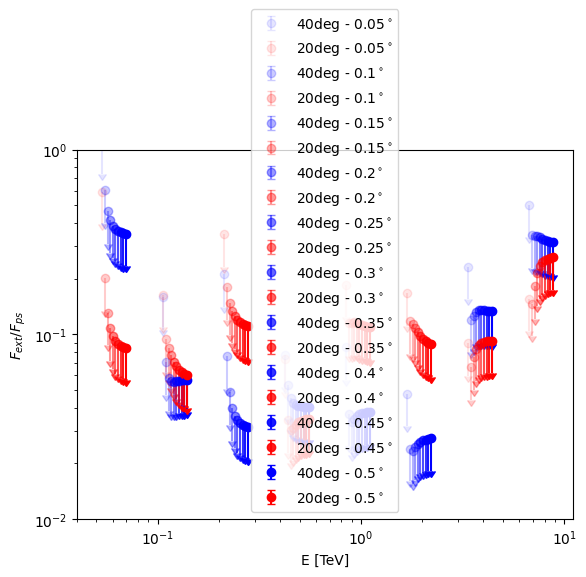

In [18]:
for i, (flux_ratio_40deg, flux_ratio_20deg) in enumerate(zip(flux_ratios_40deg, flux_ratios_20deg)):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_40deg,flux_ratio_40deg/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='blue')
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_20deg,flux_ratio_20deg/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01, 1)
plt.legend()

In [ ]:
def calculate_UL_merged(cts_40deg, cts_err_40deg, psf_hbu_40deg, cts_20deg, cts_err_20deg, psf_hbu_20deg):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))
    th2_extended = np.concatenate([th2, th2])
    
    for i, ((ct_40deg, ct_err_40deg), (ct_20deg, ct_err_20deg)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
        ct = np.concatenate([ct_40deg, ct_20deg])
        ct_err = np.concatenate([ct_err_40deg, ct_err_20deg])
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1_40deg, sigma_2_40deg, sigma_3_40deg, scale_40deg, ampl_2_40deg, ampl_3_40deg = psf_hbu_40deg.data[psf_index][0]
        sigma_1_20deg, sigma_2_20deg, sigma_3_20deg, scale_20deg, ampl_2_20deg, ampl_3_20deg = psf_hbu_20deg.data[psf_index][0]
        
        # Normalization of the PSF model to fit best the blazar
        def psf_model_40deg(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1_40deg**2))
            gauss2 = ampl_2_40deg * np.exp(-th2 / (2 * sigma_2_40deg**2))
            gauss3 = ampl_3_40deg * np.exp(-th2 / (2 * sigma_3_40deg**2))
            return (gauss1 + gauss2 + gauss3)
         
        def psf_model_20deg(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1_20deg**2))
            gauss2 = ampl_2_20deg * np.exp(-th2 / (2 * sigma_2_20deg**2))
            gauss3 = ampl_3_20deg * np.exp(-th2 / (2 * sigma_3_20deg**2))
            return (gauss1 + gauss2 + gauss3)

        psf_component_40deg = psf_model_40deg(th2)
        psf_component_20deg = psf_model_20deg(th2)

        psf_component_40deg = sum(ct_40deg) * psf_component_40deg / sum(psf_component_40deg)
        psf_component_20deg = sum(ct_20deg) * psf_component_20deg / sum(psf_component_20deg)

        psf_component_err_40deg = np.zeros_like(psf_component_40deg)
        psf_component_err_20deg = np.zeros_like(psf_component_20deg)

        chi2_noext_40deg = np.sum(((ct_40deg - psf_component_40deg)**2 / (ct_err_40deg**2 + psf_component_err_40deg**2)))
        chi2_noext_20deg = np.sum(((ct_20deg - psf_component_20deg)**2 / (ct_err_20deg**2 + psf_component_err_20deg**2)))
    
        step = 1.01
        
        chi2_noext_best_40deg = 1e10
        adjust_40deg = 1
        while chi2_noext_40deg < chi2_noext_best_40deg:
            chi2_noext_best_40deg = chi2_noext_40deg
            
            chisq0 = sum((ct_40deg - step*adjust_40deg*psf_component_40deg)**2 / 
                         (ct_err_40deg**2 + (step*adjust_40deg*psf_component_err_40deg)**2))
            chisq1 = sum((ct_40deg - adjust_40deg*psf_component_40deg/step)**2 / 
                         (ct_err_40deg**2 + (adjust_40deg*psf_component_err_40deg/step)**2))
            chisq_vec = np.array([chisq0, chisq1])
            chi2_noext_40deg = min(chisq_vec)
            ind = np.argmin(chisq_vec)
            
            if chi2_noext_40deg < chi2_noext_best_40deg:
                if ind == 0:
                    adjust_40deg *= step
                elif ind == 1:
                    adjust_40deg /= step

        chi2_noext_best_20deg = 1e10
        adjust_20deg = 1
        while chi2_noext_20deg < chi2_noext_best_20deg:
            chi2_noext_best_20deg = chi2_noext_20deg
            
            chisq0 = sum((ct_20deg - step*adjust_20deg*psf_component_20deg)**2 / 
                         (ct_err_20deg**2 + (step*adjust_20deg*psf_component_err_20deg)**2))
            chisq1 = sum((ct_20deg - adjust_20deg*psf_component_20deg/step)**2 / 
                         (ct_err_20deg**2 + (adjust_20deg*psf_component_err_20deg/step)**2))
            chisq_vec = np.array([chisq0, chisq1])
            chi2_noext_20deg = min(chisq_vec)
            ind = np.argmin(chisq_vec)
            
            if chi2_noext_20deg < chi2_noext_best_20deg:
                if ind == 0:
                    adjust_20deg *= step
                elif ind == 1:
                    adjust_20deg /= step

        psf_component_40deg *= adjust_40deg
        psf_component_err_40deg *= adjust_40deg
        psf_component_20deg *= adjust_20deg
        psf_component_err_20deg *= adjust_20deg

        psf_component_40deg_noext_best = psf_component_40deg
        psf_component_20deg_noext_best = psf_component_20deg
        psf_component_err_40deg_noext_best = psf_component_err_40deg
        psf_component_err_20deg_noext_best = psf_component_err_20deg
        
        chi2_noext = np.sum(((ct_40deg - psf_component_40deg)**2 / (ct_err_40deg**2))) + np.sum(((ct_20deg - psf_component_20deg)**2 / (ct_err_20deg**2))) 

        fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='row', gridspec_kw={'height_ratios': [2, 1], 'width_ratios': [1, 1]})
        fig.subplots_adjust(hspace=0, wspace=0.3)
        
        axs[0,0].errorbar(th2,ct_40deg,ct_err_40deg,linestyle='none',marker='o',label=name,color='black')
        axs[0,0].plot(th2,psf_component_40deg,color='black',linestyle='dashed',label='PSF')
        axs[0,0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1,0].errorbar(th2,ct_40deg - psf_component_40deg,np.sqrt(ct_err_40deg**2+psf_component_err_40deg**2),marker='o',linestyle='none',color='black')
        axs[1,0].axhline(0,color='black',linestyle='dashed')
        axs[0,1].errorbar(th2,ct_20deg,ct_err_20deg,linestyle='none',marker='o',label=name,color='black')
        axs[0,1].plot(th2,psf_component_20deg,color='black',linestyle='dashed',label='PSF')
        axs[0,1].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1,1].errorbar(th2,ct_20deg - psf_component_20deg,np.sqrt(ct_err_20deg**2+psf_component_err_20deg**2),marker='o',linestyle='none',color='black')
        axs[1,1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            psf_component_40deg = psf_component_40deg_noext_best     
            psf_component_20deg = psf_component_20deg_noext_best     
            psf_component_err_40deg = psf_component_err_40deg_noext_best 
            psf_component_err_20deg = psf_component_err_20deg_noext_best 
            
            def ext_model_40deg(th2):
                sigma1_conv = np.sqrt(sigma_1_40deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_40deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_40deg**2 + sigma_ext**2)
                c1 = sigma_1_40deg/(sigma_1_40deg**2 + sigma_ext**2)
                c2 = ampl_2_40deg*sigma_2_40deg/(sigma_2_40deg**2 + sigma_ext**2)
                c3 = ampl_3_40deg*sigma_3_40deg/(sigma_3_40deg**2 + sigma_ext**2)
                gauss1_conv = c1 * np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = c2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = c3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return (gauss1_conv + gauss2_conv + gauss3_conv)

            def ext_model_20deg(th2):
                sigma1_conv = np.sqrt(sigma_1_20deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_20deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_20deg**2 + sigma_ext**2)
                c1 = sigma_1_20deg/(sigma_1_20deg**2 + sigma_ext**2)
                c2 = ampl_2_20deg*sigma_2_20deg/(sigma_2_20deg**2 + sigma_ext**2)
                c3 = ampl_3_20deg*sigma_3_20deg/(sigma_3_20deg**2 + sigma_ext**2)
                gauss1_conv = c1 * np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = c2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = c3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return (gauss1_conv + gauss2_conv + gauss3_conv)

            ct_ext_40deg = ext_model_40deg(th2)
            ct_ext_20deg = ext_model_20deg(th2)
            print(f"ext_model_20deg sum = {sum(ct_ext_20deg)}")

            ct_ext_40deg = sum(ct_40deg) * ct_ext_40deg / sum(ct_ext_40deg)
            ct_ext_20deg = sum(ct_20deg) * ct_ext_20deg / sum(ct_ext_20deg)
            print(f"after normalization sum = {sum(ct_ext_20deg)}")

            chi2_ext_40deg = np.sum(((ct_40deg - ct_ext_40deg - psf_component_40deg)**2 / (ct_err_40deg**2 + psf_component_err_40deg**2)))
            chi2_ext_20deg = np.sum(((ct_20deg - ct_ext_20deg - psf_component_20deg)**2 / (ct_err_20deg**2 + psf_component_err_20deg**2)))

            step = 1.01
            
            chi2_ext_best_40deg = 1e10
            adjust_ext_40deg = 1
            adjust_point_40deg = 1
            
            while chi2_ext_40deg < chi2_ext_best_40deg:
                chi2_ext_best_40deg = chi2_ext_40deg
                
                chisq0 = sum((ct_40deg - step*adjust_point_40deg*psf_component_40deg - adjust_ext_40deg*ct_ext_40deg)**2 / 
                             (ct_err_40deg**2 + (step*adjust_point_40deg*psf_component_err_40deg)**2))
                chisq1 = sum((ct_40deg - adjust_point_40deg*psf_component_40deg/step - adjust_ext_40deg*ct_ext_40deg)**2 / 
                             (ct_err_40deg**2 + (adjust_point_40deg*psf_component_err_40deg/step)**2))
                chisq2 = sum((ct_40deg - adjust_point_40deg*psf_component_40deg - step*adjust_ext_40deg*ct_ext_40deg)**2 / 
                             (ct_err_40deg**2 + adjust_point_40deg*psf_component_err_40deg**2))
                chisq3 = sum((ct_40deg - adjust_point_40deg*psf_component_40deg - adjust_ext_40deg*ct_ext_40deg/step)**2 / 
                             (ct_err_40deg**2 + adjust_point_40deg*psf_component_err_40deg**2))
                
                chisq_vec = np.array([chisq0, chisq1, chisq2, chisq3])
                chi2_ext_40deg = min(chisq_vec)
                ind = np.argmin(chisq_vec)
                
                if chi2_ext_40deg < chi2_ext_best_40deg:
                    if ind == 0:
                        adjust_point_40deg *= step
                    if ind == 1:
                        adjust_point_40deg /= step
                    if ind == 2:
                        adjust_ext_40deg *= step
                    if ind == 3:
                        adjust_ext_40deg /= step

            chi2_ext_best_20deg = 1e10
            adjust_ext_20deg = 1
            adjust_point_20deg = 1
            
            while chi2_ext_20deg < chi2_ext_best_20deg:
                chi2_ext_best_20deg = chi2_ext_20deg
                
                chisq0 = sum((ct_20deg - step*adjust_point_20deg*psf_component_20deg - adjust_ext_20deg*ct_ext_20deg)**2 / 
                             (ct_err_20deg**2 + (step*adjust_point_20deg*psf_component_err_20deg)**2))
                chisq1 = sum((ct_20deg - adjust_point_20deg*psf_component_20deg/step - adjust_ext_20deg*ct_ext_20deg)**2 / 
                             (ct_err_20deg**2 + (adjust_point_20deg*psf_component_err_20deg/step)**2))
                chisq2 = sum((ct_20deg - adjust_point_20deg*psf_component_20deg - step*adjust_ext_20deg*ct_ext_20deg)**2 / 
                             (ct_err_20deg**2 + adjust_point_20deg*psf_component_err_20deg**2))
                chisq3 = sum((ct_20deg - adjust_point_20deg*psf_component_20deg - adjust_ext_20deg*ct_ext_20deg/step)**2 / 
                             (ct_err_20deg**2 + adjust_point_20deg*psf_component_err_20deg**2))
                
                chisq_vec = np.array([chisq0, chisq1, chisq2, chisq3])
                chi2_ext_20deg = min(chisq_vec)
                ind = np.argmin(chisq_vec)
                
                if chi2_ext_20deg < chi2_ext_best_20deg:
                    if ind == 0:
                        adjust_point_20deg *= step
                    if ind == 1:
                        adjust_point_20deg /= step
                    if ind == 2:
                        adjust_ext_20deg *= step
                    if ind == 3:
                        adjust_ext_20deg /= step
            
            ct_ext_40deg *= adjust_ext_40deg
            psf_component_40deg *= adjust_point_40deg
            psf_component_err_40deg *= adjust_point_40deg

            ct_ext_20deg *= adjust_ext_20deg
            psf_component_20deg *= adjust_point_20deg
            psf_component_err_20deg *= adjust_point_20deg

            # From now on i keep the calues concatenated. I'm renomalizing the extended component equally for the two zenith angles.
            # This might be wrong, I still have to think about it.
            ct_ext = np.concatenate([ct_ext_40deg, ct_ext_20deg])
            psf_component = np.concatenate([psf_component_40deg, psf_component_20deg])
            psf_component_err = np.concatenate([psf_component_err_40deg, psf_component_err_20deg])
            cts_tot_best = np.sum(ct_ext + psf_component)
            chi2_ext = np.sum(((ct - ct_ext - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
            
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")
            axs[0,0].plot(th2,ct_ext[:len(th2)],color='red',alpha=0.5,marker='+', linestyle="none",label='extended source best fit')
            axs[0,1].plot(th2,ct_ext[len(th2):],color='red',alpha=0.5,marker='+', linestyle="none",label='extended source best fit')

            # Upper limits
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point_20deg_ul = 1
            adjust_point_40deg_ul = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext

                    chisq0 = sum((ct - ct_ext - np.concatenate([step*adjust_point_40deg_ul*psf_component_40deg, 
                                                                 adjust_point_20deg_ul*psf_component_20deg]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)

                    chisq1 = sum((ct - ct_ext - np.concatenate([adjust_point_40deg_ul*psf_component_40deg/step, 
                                                                 adjust_point_20deg_ul*psf_component_20deg]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)
                    
                    chisq2 = sum((ct - ct_ext - np.concatenate([adjust_point_40deg_ul*psf_component_40deg, 
                                                                 step*adjust_point_20deg_ul*psf_component_20deg]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)
                    
                    chisq3 = sum((ct - ct_ext - np.concatenate([adjust_point_40deg_ul*psf_component_40deg, 
                                                                 adjust_point_20deg_ul*psf_component_20deg/step]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)
                    
                    chisq_vec = np.array([chisq0, chisq1, chisq2, chisq3])
                    chi2_ext = min(chisq_vec)
                    ind = np.argmin(chisq_vec)
                    
                    if chi2_ext < chi2_ext_best_fixed_ext:
                        if ind == 0:
                            adjust_point_40deg_ul *= step
                        elif ind == 1:
                            adjust_point_40deg_ul /= step
                        elif ind == 2:
                            adjust_point_20deg_ul *= step
                        elif ind == 3:
                            adjust_point_20deg_ul /= step

            flux_ratio = np.sum(ct_ext)/cts_tot_best
            flux_ratios[k][i] = flux_ratio
            axs[0,0].plot(th2,ct_ext[:len(th2)],color='blue',alpha=0.5,marker='+', linestyle="none",label='extended source U.L.')
            axs[0,1].plot(th2,ct_ext[len(th2):],color='blue',alpha=0.5,marker='+', linestyle="none",label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0,0].set_ylabel('Counts')
        axs[0,0].legend()
        axs[0,0].set_yscale('log')
        axs[0,1].set_ylabel('Counts')
        axs[0,1].legend()
        axs[0,1].set_yscale('log')
        plt.show()
    return flux_ratios

In [ ]:
flux_ratios = calculate_UL_merged(cts_40deg, cts_err_40deg, psf_hbu_40deg, cts_20deg, cts_err_20deg, psf_hbu_20deg)

In [ ]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,np.abs(flux_ratio/3), alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel(r"$E$, TeV")
plt.xlim(0.04,11)
plt.ylim(0.005, 0.5)
plt.legend()
plt.title(f"{name}")
#plt.savefig(f'./images/UL_{name}_DC.png', dpi=600, bbox_inches='tight')
plt.show()

for i, (flux_ratio_40deg, flux_ratio_20deg) in enumerate(zip(flux_ratios_40deg, flux_ratios_20deg)):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_40deg,flux_ratio_40deg/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='blue')
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_20deg,flux_ratio_20deg/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel(r"$E$, TeV")
plt.xlim(0.04,11)
plt.ylim(0.005, 0.5)
plt.legend()
plt.title(f"{name}")
#plt.savefig(f'./images/UL_{name}_DC_2angles.png', dpi=600, bbox_inches='tight')

In [ ]:
koro_energies = [0.5, 1.5, 1.5, 4, 4, 10]
red_ratios = [0.0031, 0.0031, 0.0083,0.0083, 0.0215,0.0215]
blue_ratios = [0.0223, 0.0223, 0.0448, 0.0448, 0.0724, 0.0724]
green_ratios = [0.0607, 0.0607, 0.0771, 0.0771, 0.0901, 0.0901]

for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,np.abs(flux_ratio/3), alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.step(koro_energies, red_ratios, where='post', color='red', linewidth=2, 
         label='Red (LB)', alpha=0.8)
plt.step(koro_energies, blue_ratios, where='post', color='blue', linewidth=2, 
         label='Blue', alpha=0.8)
plt.step(koro_energies, green_ratios, where='post', color='green', linewidth=2, 
         label=r'$B=10^{-12}$Korochkin et al. 21', alpha=0.8)
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel(r"$E$, TeV")
plt.xlim(0.04,11)
plt.ylim(0.0005, 0.5)
plt.legend()
plt.grid()
plt.title(f"{name}")
#plt.savefig(f'./images/UL_{name}_DC_PLUS_KORO.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
flux_ratios.shape

In [ ]:
if name == "Mrk421":
    z = 0.03
else:
    z = 0.033
B0 = np.array([5, 10, 20, 40])*10**(-15) # G
lambda_b = 10 # kpc
E_mat = e[:, np.newaxis] # column
B0_mat = B0[np.newaxis, :] # row

E_prime = np.sqrt(E_mat/0.33)*20
delta = 5*10**(-7)*(20/E_prime)**(3/2)*(B0/10**(-18))*(lambda_b)**(1/2)
#delta = 3*10**(-6)*(B0/10**(-18))*(E_prime/20)**(-2)
D_gamma = 40*20/E_prime
tau = 130/D_gamma

#theta_theor = D_gamma*delta/130
#theta_theor = delta/tau
theta_theor = 0.07*(1+z)**(-1/2)*(tau/10)**(-1)*(E_mat/0.1)**(-3/4)*(B0/10**(-14))*(lambda_b)**(1/2)


plt.plot(np.log10(E_mat), theta_theor[:, 0], 'white', linewidth=2, label=f"B0 = {B0_mat[0,0]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 1], 'white', linewidth=2, linestyle='--', label=f"B0 = {B0_mat[0,1]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 2], 'white', linewidth=2, linestyle=':', label=f"B0 = {B0_mat[0,2]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 3], 'white', linewidth=2, linestyle='-.', label=f"B0 = {B0_mat[0,3]:.0e} G")


plt.xlabel("log(E/TeV)")
plt.ylabel("θ, deg")
plt.legend()
plt.title(f"{name}")

plt.imshow(np.log10(flux_ratios), extent=[np.log10(e[0]), np.log10(e[-1]), sigmas_ext[0], sigmas_ext[-1]], aspect='auto', origin='lower')
plt.colorbar(label=r"$log(F_{ext}/F_{ps})$")
#plt.savefig(f'./images/UL_{name}_DC_COMPLETE.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
def extr_data_from_csv(filepath):
    tot_datapoints = 10
    data = np.genfromtxt(filepath, delimiter=",", skip_header=1)

    if data.size == 0:
        return np.zeros(tot_datapoints)

    if data.ndim == 1:
        values = data
    else:
        values = data[:, 1] if data.shape[1] > 1 else data[:, 0]

    if len(values) < tot_datapoints:
        values = np.append(values, np.zeros(tot_datapoints - len(values)))

    return values

In [ ]:
ext_sim_flux = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux.csv")
ext_sim_flux_up = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux_errup.csv")
ext_sim_flux_down = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux_errdown.csv")

In [ ]:
from scipy.interpolate import RegularGridInterpolator
linestyles = ["-", "--", ":", "-."]
starting_relevancy = [10**(-1), 10**(-0.75), 10**(-0.5), 10**(-0.25)]
for i, col_idx in enumerate(range(len(B0))):
    logE = np.log10(E_mat[:, 0])
    theta_curve = theta_theor[:, col_idx]
    
    logE_grid = np.log10(E_mat[:, 0])
    sigma_grid = sigmas_ext
    
    interpolator = RegularGridInterpolator((sigma_grid, logE_grid), 
                                           np.log10(flux_ratios), 
                                           bounds_error=False, 
                                           fill_value=None)
    
    points = np.column_stack([theta_curve, logE])
    flux_ratios_on_curve = 10**interpolator(points)
    print(flux_ratios_on_curve)

    if i==0:
        index_in = 3
        index_fin_rel = 4
    if i==1:
        index_in = 4
        index_fin_rel = 3
    if i==2:
        index_in = 5
        index_fin_rel = 2
    if i==3:
        index_in = 6
        index_fin_rel = 1
    plt.plot(E_mat[index_in:-index_fin_rel, 0], flux_ratios_on_curve[index_in:-index_fin_rel], color="black", alpha=1+0.25*i, linestyle=linestyles[i])
    plt.errorbar(E_mat[index_in:-index_fin_rel, 0], flux_ratios_on_curve[index_in:-index_fin_rel],np.abs(flux_ratios_on_curve[index_in:-index_fin_rel]/3), alpha=0.25+0.25*i, uplims=True, linestyle='none',marker='o', label=f"B0 = {B0[i]:.0e} G",color='black')
plt.plot(E_mat[:, 0], ext_sim_flux, color="blue")
plt.fill_between(E_mat[:, 0], ext_sim_flux_down, ext_sim_flux_up, color='blue', alpha=0.3)
plt.ylim([0.005, 0.5])
plt.xlim([0.05, 5])
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$E$, TeV")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.legend()
plt.title(f"{name}")
plt.savefig(f'./images/UL_{name}_DC_SIM_FINAL.png', dpi=600, bbox_inches='tight')